In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import os
import scipy.io as sio
import pandas as pd
import numpy as np

# 1. Aapke Google Drive wale folder ka path jahan saari .mat files hain
folder_path = '/content/drive/MyDrive/Ev_Battery'
master_list = []

print("⏳ Files ko ek DataFrame me merge karna shuru ho raha hai...")

# 2. Saari files ko scan aur merge karna
for root, dirs, files in os.walk(folder_path):
    for file_name in files:
        if file_name.endswith('.mat'):
            battery_id = file_name.split('.')[0] # Jaise: B0005
            file_path = os.path.join(root, file_name)

            try:
                mat = sio.loadmat(file_path)
                data = mat[battery_id]
                cycles = data[0, 0]['cycle'][0]

                for i, cycle in enumerate(cycles):
                    if cycle['type'][0] == 'discharge':
                        cycle_data = cycle['data'][0, 0]
                        voltage = cycle_data['Voltage_measured'][0]
                        current = cycle_data['Current_measured'][0]
                        temp = cycle_data['Temperature_measured'][0]
                        capacity = cycle_data['Capacity'][0][0] if len(cycle_data['Capacity']) > 0 else np.nan

                        for v, c, t in zip(voltage, current, temp):
                            master_list.append({
                                'Battery_ID': battery_id,
                                'Cycle_Num': i,
                                'Voltage': v,
                                'Current': c,
                                'Temperature': t,
                                'Capacity': capacity
                            })
            except Exception as e:
                # Agar kisi file me error aaye (jaise crashed files), toh usko skip kar do
                continue

# 3. Aapka final DataFrame 'df' ke naam se tayyar hai!
df = pd.DataFrame(master_list)

print("\n✅ Saari files successfully ek DataFrame 'df' me merge ho gayi hain!")
print(f"📊 Total Rows (Lakhs me) hamare paas aayi hain: {df.shape[0]}")

⏳ Files ko ek DataFrame me merge karna shuru ho raha hai...

✅ Saari files successfully ek DataFrame 'df' me merge ho gayi hain!
📊 Total Rows (Lakhs me) hamare paas aayi hain: 764674


In [20]:
df.head()

,Battery_ID,Cycle_Num,Voltage,Current,Temperature,Capacity
0,B0032,1,4.087016,-0.003006,43.265234,1.704864
1,B0032,1,4.086934,-0.000235,43.256832,1.704864
2,B0032,1,3.718468,-3.990765,43.311729,1.704864
3,B0032,1,3.694684,-3.988640,43.445612,1.704864
4,B0032,1,3.676322,-3.989156,43.611781,1.704864


In [21]:
df.tail()

,Battery_ID,Cycle_Num,Voltage,Current,Temperature,Capacity
764669,B0055,250,3.728439,0.001585,13.405031,0.990759
764670,B0055,250,3.729747,0.000097,13.282155,0.990759
764671,B0055,250,3.731507,-0.000431,13.059522,0.990759
764672,B0055,250,3.732974,-0.000321,12.831632,0.990759
764673,B0055,250,3.734484,-0.000687,12.690525,0.990759


In [27]:
df.sample(5)

,Battery_ID,Cycle_Num,Voltage,Current,Temperature,Capacity
287628,B0034,266,3.192228,-4.027017,36.745415,1.391765
489271,B0030,53,3.080143,-4.027142,59.907737,1.648481
660331,B0045,48,3.707428,-0.000094,5.895696,0.740726
69945,B0028,65,3.812123,-0.001303,29.797954,1.759771
719223,B0043,22,3.664895,-1.988338,27.459685,1.635366


In [23]:
df.columns

Index(['Battery_ID', 'Cycle_Num', 'Voltage', 'Current', 'Temperature',
       'Capacity'],
      dtype='object')

In [24]:
df.shape

(764674, 6)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 764674 entries, 0 to 764673
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Battery_ID   764674 non-null  object 
 1   Cycle_Num    764674 non-null  int64  
 2   Voltage      764674 non-null  float64
 3   Current      764674 non-null  float64
 4   Temperature  764674 non-null  float64
 5   Capacity     764674 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 35.0+ MB


## Data Cleaning

In [28]:
df.isnull().sum()

,0
Battery_ID,0
Cycle_Num,0
Voltage,0
Current,0
Temperature,0
Capacity,0


In [30]:
print("\nData summary:\n",df.describe())


Data summary:
            Cycle_Num        Voltage        Current    Temperature  \
count  764674.000000  764674.000000  764674.000000  764674.000000   
mean      156.207032       3.438581      -1.589611      27.433162   
std       144.093017       0.332364       1.158429      13.994716   
min         0.000000       0.192738      -4.038796       2.904756   
25%        46.000000       3.287356      -2.010812      11.670308   
50%       105.000000       3.476047      -1.989298      30.153036   
75%       232.000000       3.665351      -0.995695      36.077054   
max       613.000000       4.542427       0.030461      69.869746   

            Capacity  
count  764674.000000  
mean        1.430708  
std         0.372062  
min         0.000000  
25%         1.263163  
50%         1.483558  
75%         1.730881  
max         2.640149  


In [31]:
df.duplicated().sum()

np.int64(0)

In [39]:
df = df.drop(columns=['Battery_ID'])

## Feature Engineering

In [32]:
def create_features(df, window_size=50):
    # Group by Battery and Cycle to ensure we don't mix data between batteries
    # Rolling mean and std over the window
    df['V_mean'] = df.groupby(['Battery_ID', 'Cycle_Num'])['Voltage'].transform(lambda x: x.rolling(window_size).mean())
    df['V_std'] = df.groupby(['Battery_ID', 'Cycle_Num'])['Voltage'].transform(lambda x: x.rolling(window_size).std())

    df['T_mean'] = df.groupby(['Battery_ID', 'Cycle_Num'])['Temperature'].transform(lambda x: x.rolling(window_size).mean())
    df['T_std'] = df.groupby(['Battery_ID', 'Cycle_Num'])['Temperature'].transform(lambda x: x.rolling(window_size).std())

    # Drop the rows created at the start of each cycle where the window wasn't full (NaN values)
    df = df.dropna()
    return df

# Run the transformation
# Warning: This might take a minute because of the 7.6L rows
df_featured = create_features(df)

# Check the new columns
print(df_featured.head())

   Battery_ID  Cycle_Num   Voltage   Current  Temperature  Capacity    V_mean  \
49      B0032          1  3.404488 -3.988309    49.777179  1.704864  3.536861   
50      B0032          1  3.400964 -3.991394    49.860534  1.704864  3.523140   
51      B0032          1  3.397641 -3.989011    50.017234  1.704864  3.509354   
52      B0032          1  3.394270 -3.989117    50.081521  1.704864  3.502870   
53      B0032          1  3.390966 -3.989392    50.174055  1.704864  3.496795   

       V_std     T_mean     T_std  
49  0.139598  46.889027  2.015266  
50  0.116170  47.020933  1.988906  
51  0.084474  47.156141  1.957335  
52  0.080442  47.291537  1.919761  
53  0.077058  47.426106  1.880083  


In [40]:
from scipy import stats

# 1. Sirf numerical columns select karo
numeric_cols = [ 'Cycle_Num',	'Voltage',	'Current',	'Temperature',	'Capacity']

# 2. Z-score calculate karo
z_scores = np.abs(stats.zscore(df[numeric_cols]))

# 3. Threshold fix karo (jo value 3 standard deviation se bahar hai, wo outlier hai)
threshold = 3
outlier_indices = np.where(z_scores > threshold)

print(f"Total outliers detected: {len(outlier_indices[0])}")

# 4. Outliers ko handle karna (Dropping them is safest for now)
df_clean = df[(z_scores < threshold).all(axis=1)]

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

# Ab 'df' ko 'df_clean' se update kar do
df = df_clean

Total outliers detected: 12083
Original shape: (729126, 9)
Cleaned shape: (717098, 9)


## EDA (Exploratory Data Analysis )

In [41]:
df['Cycle_Num'].describe()

,Cycle_Num
count,717098.000000
mean,152.005466
std,137.536464
min,0.000000
25%,46.000000
50%,101.000000
75%,231.000000
max,571.000000


Text(0, 0.5, 'Frequency')

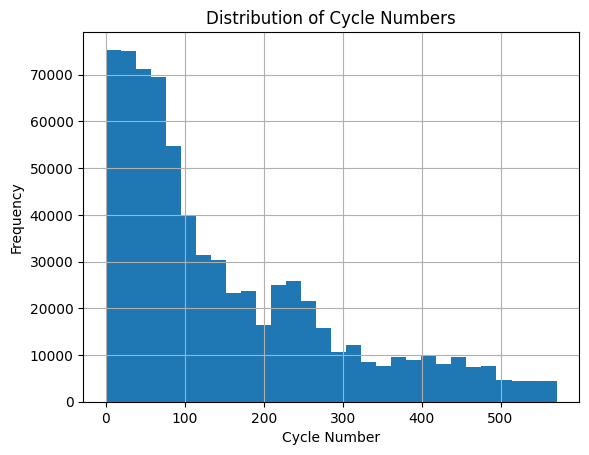

In [44]:
df['Cycle_Num'].hist(bins=30)
plt.title("Distribution of Cycle Numbers")
plt.xlabel("Cycle Number")
plt.ylabel("Frequency")

In [45]:
df['Voltage'].describe()

,Voltage
count,717098.000000
mean,3.455864
std,0.277480
min,2.581228
25%,3.301977
50%,3.479513
75%,3.662397
max,4.297261


Text(0, 0.5, 'Frequency')

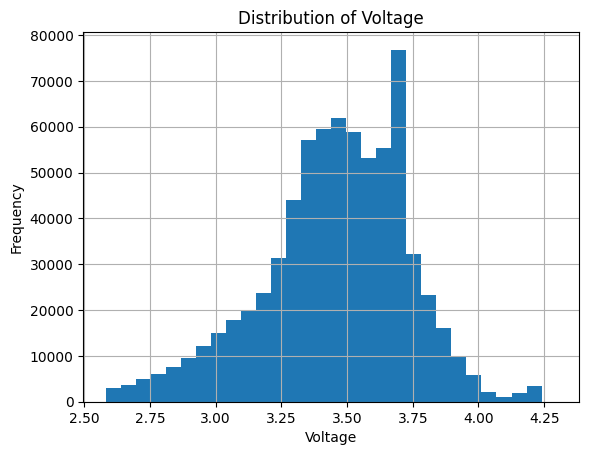

In [46]:
df['Voltage'].hist(bins=30)
plt.title("Distribution of Voltage")
plt.xlabel("Voltage")
plt.ylabel("Frequency")

In [47]:
df['Current'].describe()

,Current
count,717098.000000
mean,-1.590267
std,1.144829
min,-4.038796
25%,-2.010636
50%,-1.989286
75%,-0.995849
max,0.030461


Text(0, 0.5, 'Frequency')

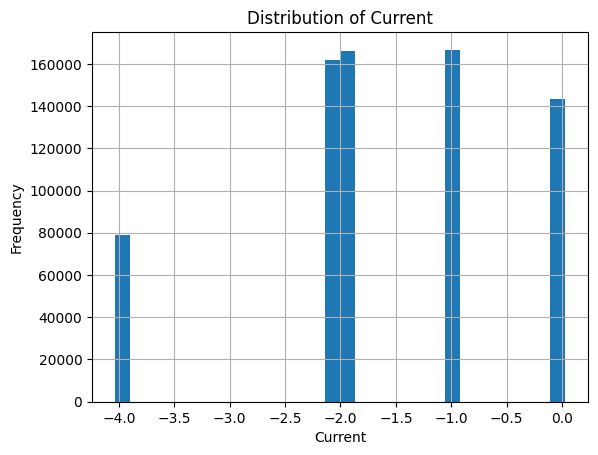

In [48]:
df['Current'].hist(bins=30)
plt.title("Distribution of Current")
plt.xlabel("Current")
plt.ylabel("Frequency")

In [50]:
df.sample(5)

,Cycle_Num,Voltage,Current,Temperature,Capacity,V_mean,V_std,T_mean,T_std
634063,36,3.568282,-1.994610,6.123554,1.191488,NaN,NaN,NaN,NaN
103482,282,2.856208,-4.030199,49.289963,1.423442,3.001283,0.073827,43.783890,3.315283
714785,116,3.326199,-2.012477,10.583572,1.012459,3.444104,0.093060,8.339512,1.800994
360626,72,3.634527,-0.997004,46.342924,1.759096,3.656258,0.013309,46.257760,0.031018
500403,60,3.656821,-2.011516,27.882681,1.644982,3.731639,0.048524,26.403432,1.174539


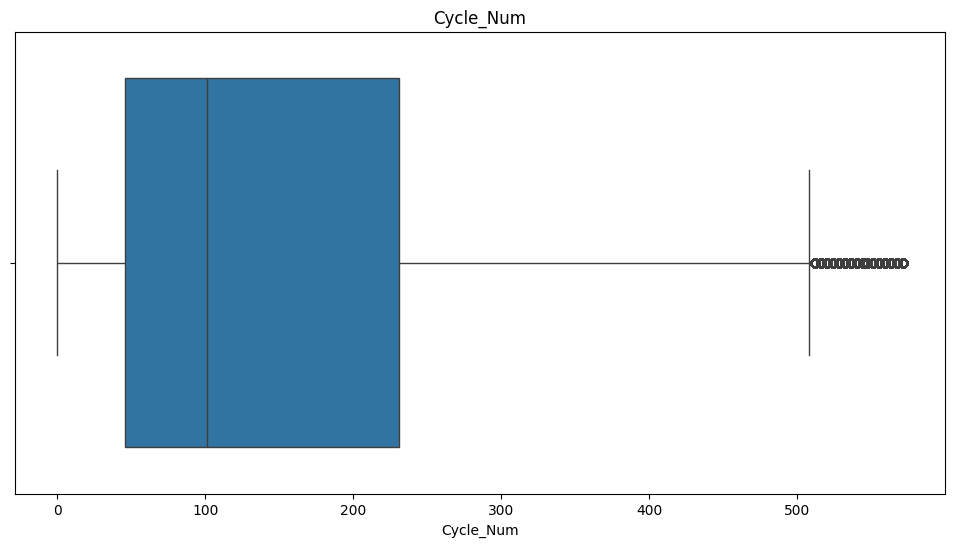

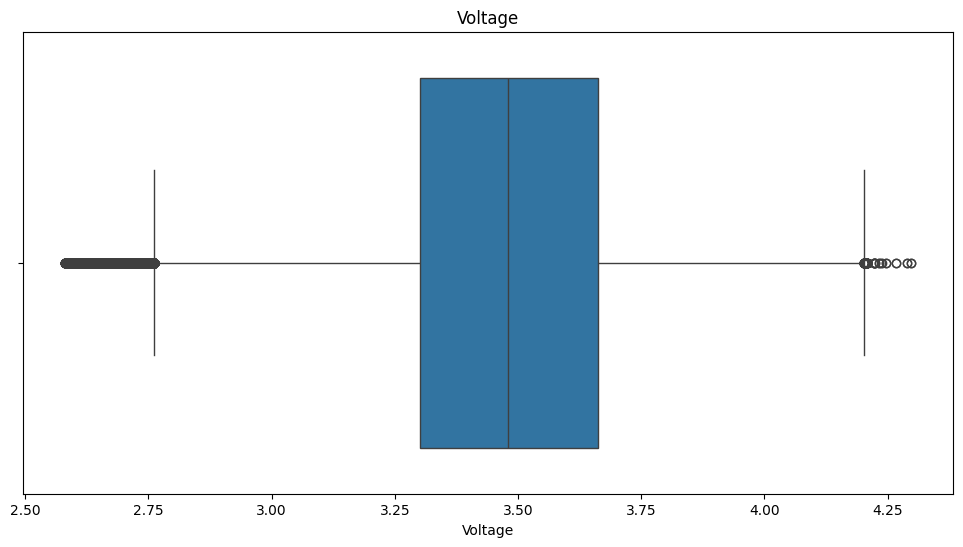

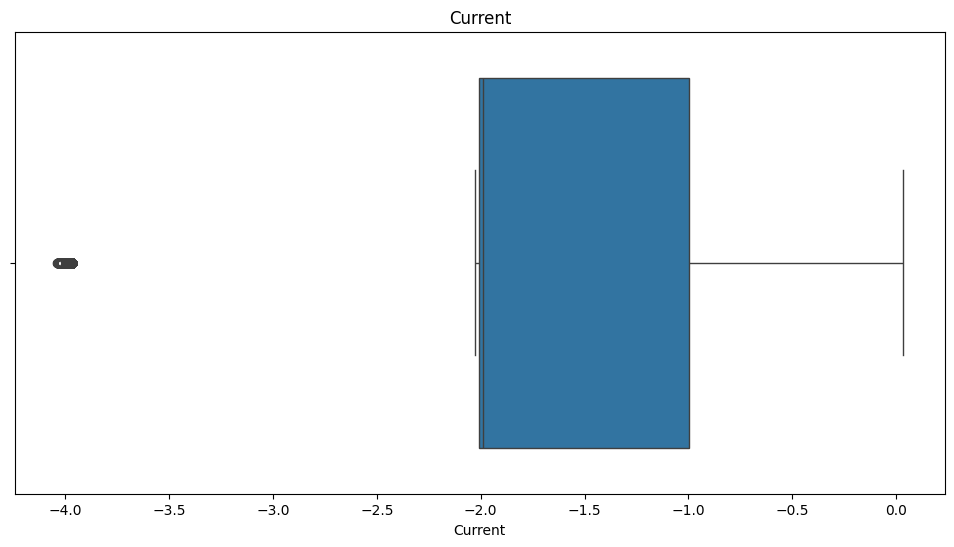

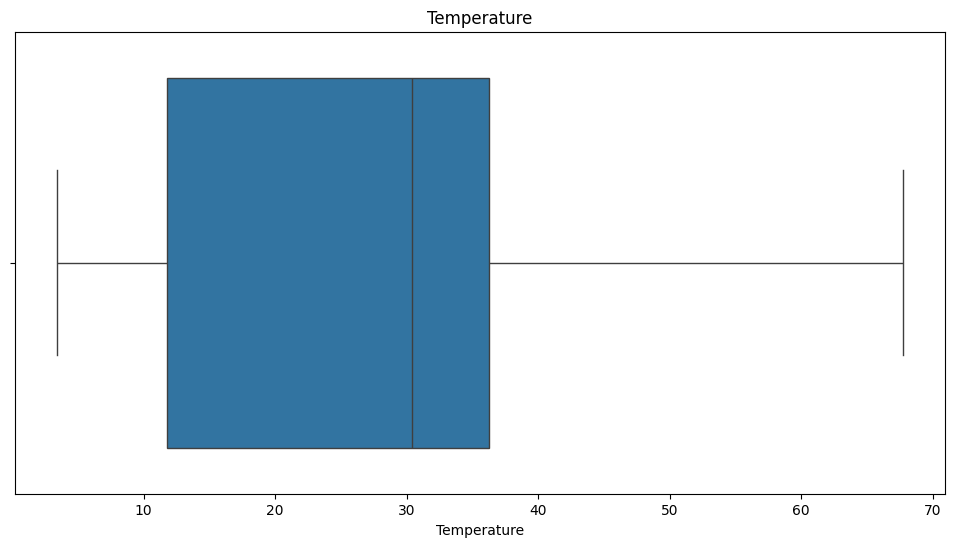

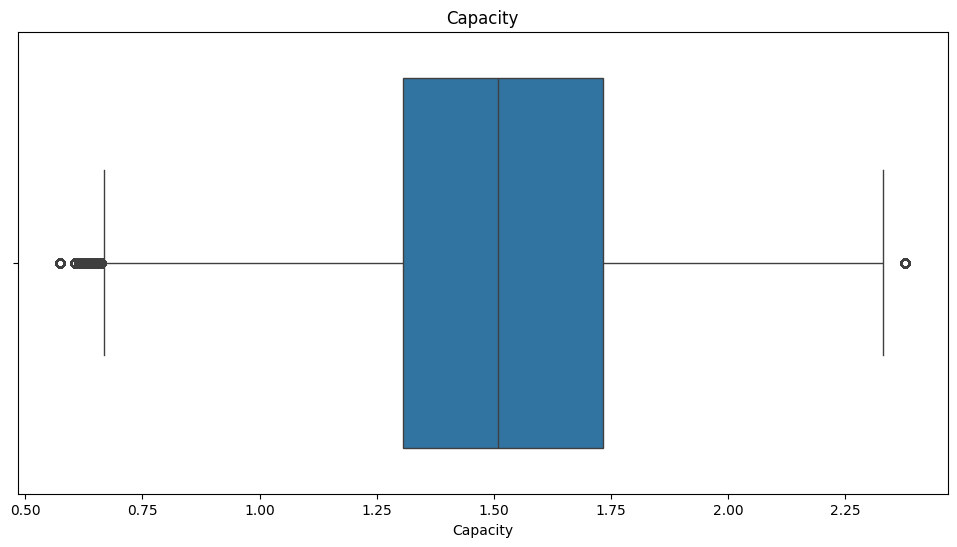

In [53]:
cols = ['Cycle_Num',	'Voltage', 'Current',	'Temperature',	'Capacity']
for col in cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

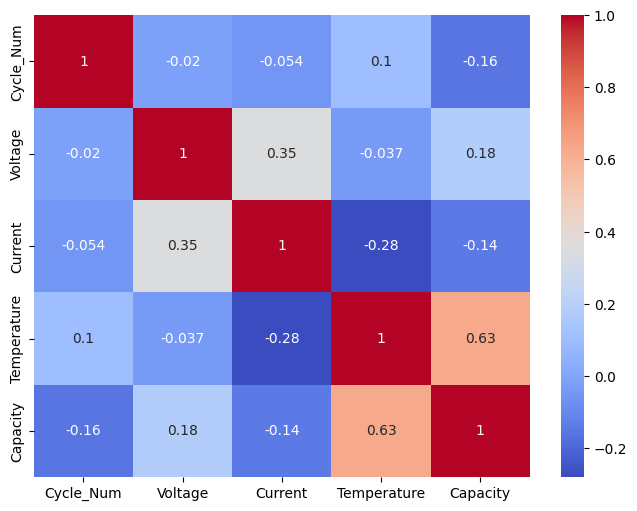

In [54]:
# Multivariate Analysis

corr=df[['Cycle_Num','Voltage','Current','Temperature','Capacity']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

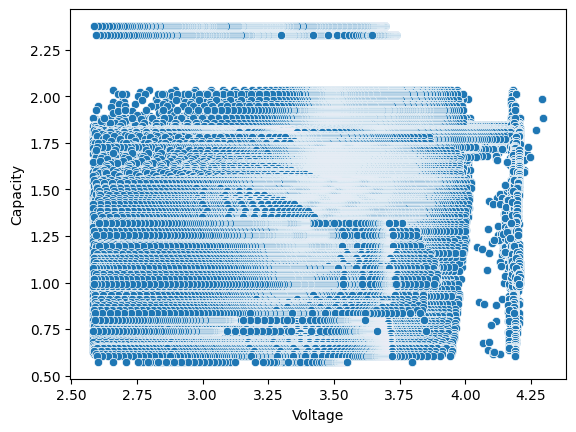

In [55]:
sns.scatterplot(
    x='Voltage',
    y='Capacity',
    data=df
)

plt.show()

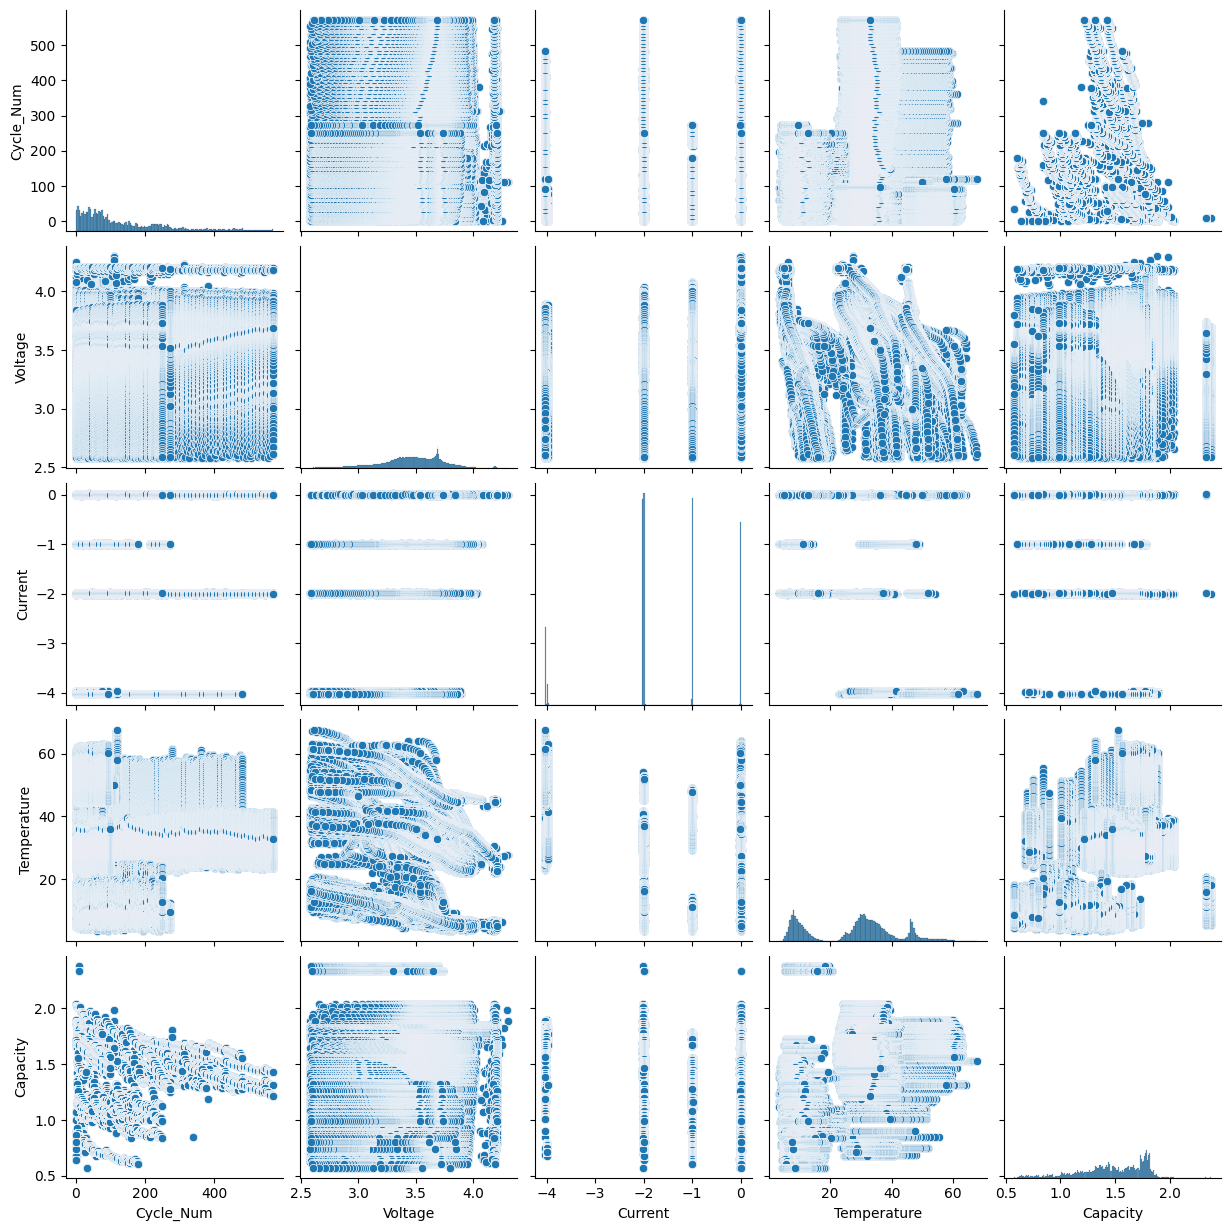

In [56]:
sns.pairplot(
    df[['Cycle_Num',
        'Voltage',
        'Current',
        'Temperature',
        'Capacity']]
)
plt.show()

In [57]:
df.sample(1)

,Cycle_Num,Voltage,Current,Temperature,Capacity,V_mean,V_std,T_mean,T_std
264255,42,3.680889,-0.002906,30.212955,1.524531,3.680017,0.000742,31.390342,0.791324


## Model Bulding

In [58]:
x = df.drop('Capacity', axis = 1)
y = df['Capacity']

In [59]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [64]:
x_train.shape, y_train.shape

((573678, 8), (573678,))

In [65]:
x_test.shape, y_test.shape

((143420, 8), (143420,))

In [66]:
df.shape

(717098, 9)

In [74]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [75]:
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [78]:
y_pred = xgb.predict(x_test)

In [79]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 Score : 0.9697604322753439
MAE : 0.027618459691725314
RMSE : 0.05175470054113655


In [80]:
# Actual VS Prediction comparion
comparison = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": y_pred[:10]
})

print(comparison)

          Actual  Predicted
400745  1.727219   1.754724
375326  1.717679   1.766662
68370   1.757706   1.757783
355925  1.770120   1.764779
685531  1.038910   1.032775
438242  1.525314   1.563915
587721  1.157683   1.169624
621059  1.161535   1.182683
251426  1.666489   1.649318
82411   1.607929   1.601947


In [82]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance)

       Feature  Importance
3  Temperature    0.626433
0    Cycle_Num    0.089449
7        T_std    0.072911
2      Current    0.067269
5        V_std    0.049824
4       V_mean    0.033334
1      Voltage    0.030398
6       T_mean    0.030381


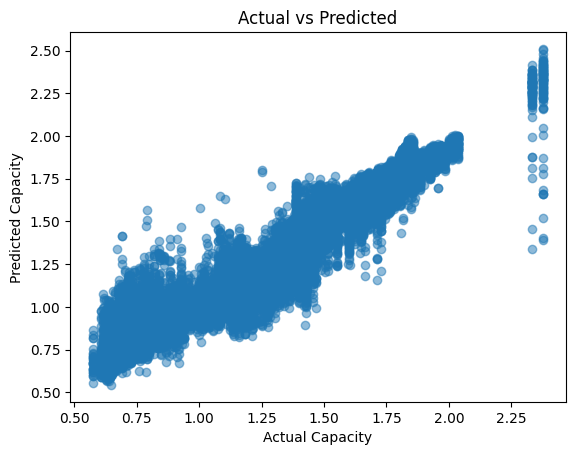

In [83]:
# Prediction Graph
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Capacity")
plt.ylabel("Predicted Capacity")
plt.title("Actual vs Predicted")
plt.show()

In [84]:
import pickle

with open('EV_Battery_XGBoost_Model.pkl', 'wb') as file:
    pickle.dump(xgb, file)

print("Model saved successfully!")

Model saved successfully!
